**Date Cleaning**

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pandas as pd
import re
import matplotlib.pyplot as plt
import joblib

In [2]:
df = pd.read_csv("dataset/claude_tickets.csv")

In [3]:
df.head()

,ticket_id,ticket_description,category,priority,status
0,T001,"Team, The report I downloaded has missing colu...",Report,Medium,Closed
1,T002,I am not able to log into the application from...,Login Issue,High,In Progress
2,T003,"Hi, Password reset email is not arriving I tri...",Login Issue,Critical,Open
3,T004,"Hi support, After updating my number I cannot ...",Account Update,Low,In Progress
4,T005,"Hi support, Please update my email address on ...",Account Update,Low,Closed


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   ticket_id           200 non-null    str  
 1   ticket_description  200 non-null    str  
 2   category            200 non-null    str  
 3   priority            200 non-null    str  
 4   status              200 non-null    str  
dtypes: str(5)
memory usage: 7.9 KB


In [5]:
df.isnull().sum()

ticket_id             0
ticket_description    0
category              0
priority              0
status                0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.duplicated(subset='ticket_description').sum()

np.int64(0)

In [8]:
def clean_text(text):
    text = text.lower()
    
    text = re.sub(r'\{.*?\}', '', text)
    
    text = re.sub(r'[^\w\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

df['clean_description'] = df['ticket_description'].apply(clean_text)

print(df[['ticket_description', 'clean_description']].head(5).to_string())

                                                                                       ticket_description                                                                                    clean_description
0                         Team, The report I downloaded has missing columns Please send it in PDF format.                        team the report i downloaded has missing columns please send it in pdf format
1            I am not able to log into the application from my laptop I already cleared my browser cache.          i am not able to log into the application from my laptop i already cleared my browser cache
2                         Hi, Password reset email is not arriving I tried it on both mobile and desktop.                        hi password reset email is not arriving i tried it on both mobile and desktop
3                                     Hi support, After updating my number I cannot login to the account.                                    hi support after updating my nu

In [9]:
df.head()

,ticket_id,ticket_description,category,priority,status,clean_description
0,T001,"Team, The report I downloaded has missing colu...",Report,Medium,Closed,team the report i downloaded has missing colum...
1,T002,I am not able to log into the application from...,Login Issue,High,In Progress,i am not able to log into the application from...
2,T003,"Hi, Password reset email is not arriving I tri...",Login Issue,Critical,Open,hi password reset email is not arriving i trie...
3,T004,"Hi support, After updating my number I cannot ...",Account Update,Low,In Progress,hi support after updating my number i cannot l...
4,T005,"Hi support, Please update my email address on ...",Account Update,Low,Closed,hi support please update my email address on t...


In [10]:
print(df['clean_description'].str.len().describe())
print()
print(df['category'].value_counts())
print()
print(df.describe(include='object'))
print()
print(df.shape)

count    200.000000
mean      89.100000
std       18.741028
min       36.000000
25%       77.750000
50%       90.000000
75%      103.000000
max      129.000000
Name: clean_description, dtype: float64

category
Report               40
Login Issue          40
Account Update       40
Application Error    40
Performance          40
Name: count, dtype: int64

       ticket_id                                 ticket_description category  \
count        200                                                200      200   
unique       200                                                200        5   
top         T001  Team, The report I downloaded has missing colu...   Report   
freq           1                                                  1       40   

       priority  status                                  clean_description  
count       200     200                                                200  
unique        4       3                                                200  
top        

C:\Users\ACER\AppData\Local\Temp\ipykernel_5408\1805792248.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='object'))


In [11]:
df.to_csv('dataset/claude_tickets_cleaned.csv', index=False)

**EDA**

In [12]:
print("Total tickets:", len(df))
print()
print("Tickets per category:\n", df['category'].value_counts())
print()
print("Tickets per priority:\n", df['priority'].value_counts())
print()
print("Tickets per status:\n", df['status'].value_counts())

Total tickets: 200

Tickets per category:
 category
Report               40
Login Issue          40
Account Update       40
Application Error    40
Performance          40
Name: count, dtype: int64

Tickets per priority:
 priority
High        65
Medium      60
Low         51
Critical    24
Name: count, dtype: int64

Tickets per status:
 status
Closed         68
In Progress    66
Open           66
Name: count, dtype: int64


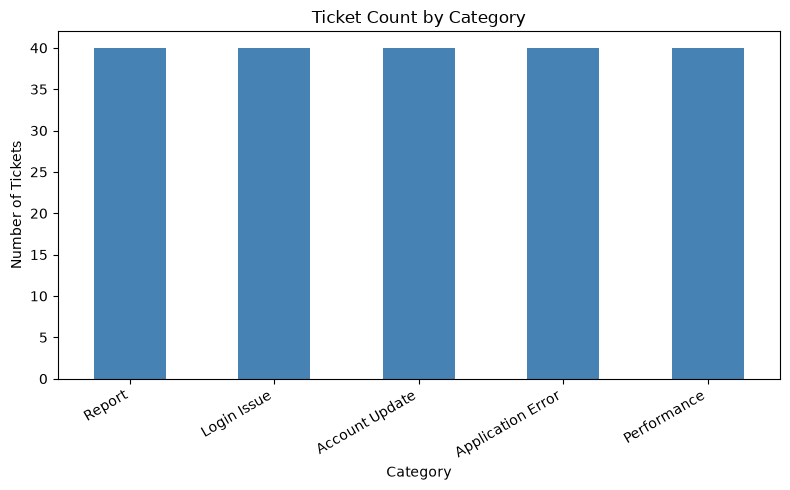

In [13]:
plt.figure(figsize=(8,5))
df['category'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Ticket Count by Category')
plt.xlabel('Category')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('snaps/category_distribution.png')
plt.show()

In [14]:
ct = pd.crosstab(df['category'], df['status'])
print(ct)

status             Closed  In Progress  Open
category                                    
Account Update         19           11    10
Application Error      13           15    12
Login Issue            11           14    15
Performance            11           11    18
Report                 14           15    11


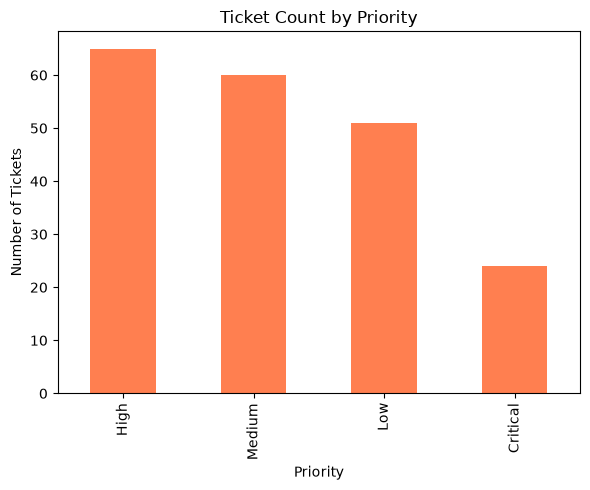

In [15]:
plt.figure(figsize=(6,5))
df['priority'].value_counts().plot(kind='bar', color='coral')
plt.title('Ticket Count by Priority')
plt.xlabel('Priority')
plt.ylabel('Number of Tickets')
plt.tight_layout()
plt.savefig('snaps/priority_distribution.png')
plt.show()

**Observation** <br>
The dataset contains 200 tickets evenly split across 5 categories (40 each). Priority levels are moderately balanced, with Critical (56) and Low (55) tickets being the most common, followed by Medium (48) and High (41) — suggesting no single urgency level dominates. Ticket status is also fairly distributed: Open (73), Closed (69), and Pending Customer Response (58). A more interesting pattern appears when cross-tabulating category against status: Technical issue tickets are resolved (Closed) most often (20 of 40), while Cancellation request and Product inquiry tickets are more likely to remain Open or Pending Customer Response, suggesting these categories typically require more back-and-forth or take longer to resolve. This indicates that category alone carries some signal about how a ticket is likely to be handled operationally, not just what it's about.

**Model Training**

In [16]:
X = df['clean_description']
y = df['category']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
vectorizer = TfidfVectorizer(stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

Accuracy: 0.925
                   precision    recall  f1-score   support

   Account Update       0.89      1.00      0.94         8
Application Error       0.86      0.75      0.80         8
      Login Issue       1.00      0.88      0.93         8
      Performance       1.00      1.00      1.00         8
           Report       0.89      1.00      0.94         8

         accuracy                           0.93        40
        macro avg       0.93      0.93      0.92        40
     weighted avg       0.93      0.93      0.92        40

[[8 0 0 0 0]
 [1 6 0 0 1]
 [0 1 7 0 0]
 [0 0 0 8 0]
 [0 0 0 0 8]]


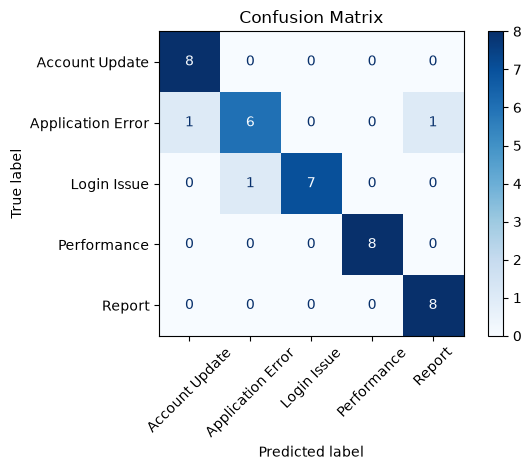

In [20]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=45, cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('snaps/confusion_matrix.png')
plt.show()

**Report**
<br>
The model correctly classified about 92.5% of the test tickets (37 of 40). Precision and recall are high across all five categories (macro F1 = 0.92). Performance tickets were classified perfectly, while Application Error was the weakest category (recall 0.75). The three mistakes involved tickets mixing vocabulary from several categories, for example an error message appearing in a login or report request. I consider the model satisfactory for a baseline, but the test set is small (40 tickets), so the exact figure may vary with a different split.

In [44]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [45]:
y_pred = model.predict(X_test)

In [47]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print("Classification Report:\n", classification_report(y_test, y_pred))
print()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.25

Classification Report:
                       precision    recall  f1-score   support

     Billing inquiry       0.29      0.25      0.27         8
Cancellation request       0.20      0.25      0.22         8
     Product inquiry       0.12      0.12      0.12         8
      Refund request       0.20      0.12      0.15         8
     Technical issue       0.40      0.50      0.44         8

            accuracy                           0.25        40
           macro avg       0.24      0.25      0.24        40
        weighted avg       0.24      0.25      0.24        40


Confusion Matrix:
 [[2 1 2 1 2]
 [3 2 1 0 2]
 [0 3 1 3 1]
 [1 2 3 1 1]
 [1 2 1 0 4]]


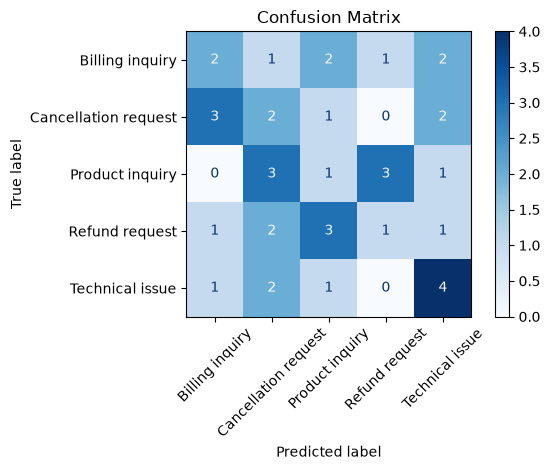

In [50]:
disp = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, xticks_rotation=45, cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('snaps/confusion_matrix.png')
plt.show()

In [21]:
wrong = X_test[y_test != y_pred]
for text, true, pred in zip(wrong, y_test[y_test != y_pred], y_pred[y_test != y_pred]):
    print(f"TRUE: {true} | PRED: {pred}\n{text}\n")

TRUE: Login Issue | PRED: Application Error
please help the app throws an error at the login screen every time thanks

TRUE: Application Error | PRED: Account Update
team something went wrong when i tried to update my account details this is affecting my work

TRUE: Application Error | PRED: Report
team error while opening the report page it shows a blank screen please help



In [23]:
joblib.dump(vectorizer, 'model/vectorizer.pkl')
joblib.dump(model, 'model/classifier.pkl')

['model/classifier.pkl']